# Lab 2: Spectral Domain Image Transforms

**Instructor:** Muhammad Sayed  
**Semester:** Spring 2026

---

### Learning Objectives
* **Dimensionality Reduction:** Mathematically compress a 13-band Sentinel-2 image using Principal Component Analysis (PCA).
* **Statistical Exploration:** Analyze the covariance and correlation of satellite bands.
* **Physical Interpretability:** Map abstract Principal Components to physical handcrafted features (Albedo, NDVI, NDWI) using quantitative L1 loss metrics.
* **Variance Interpretation:** Analyze what PCA isolates in the lower-variance components.

### Autograding Advisory
This notebook is designed for automated grading. You will find `TODO` comments throughout the code cells; ensure you assign your mathematical results to the exact variable names requested. 

At the end of the notebook, there is a submission dictionary. **You are expected to modify this dictionary structure** to include your student IDs, your answers to the analysis questions, and any notes you wish to leave for the instructor.


In [36]:
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import warnings

from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")

### 1. Data Loading & Flattening
We are loading `hazy_cufe.tiff`, a 13-band Level-1C Sentinel-2 image. To perform linear algebra, we must flatten the spatial dimensions into a 2D matrix.

In [37]:
image_path = "hazy_cufe.tiff"

with rasterio.open(image_path) as src:
    img_3d = src.read().astype(np.float32)

print(f"Original Shape: {img_3d.shape}")

# TODO: Flatten img_3d into a 2D matrix named 'X'.
# Think carefully about how dimensions align in memory during a reshape operation.
X = img_3d.reshape(img_3d.shape[0], -1).T  # Transpose to get (num_pixels, num_bands)

print(f"Flattened Shape: {X.shape}")

Original Shape: (13, 519, 519)
Flattened Shape: (269361, 13)


### 2. Statistical Exploration
Multispectral bands are often highly correlated. Let's prove it statistically.

In [38]:
# TODO: Calculate the 13x13 correlation matrix.
corr = np.corrcoef(X, rowvar=False)  # Compute correlation matrix


# TODO: Find the maximum and minimum correlation values between any two *different* bands.
# Store them in variables named 'max_corr' and 'min_corr'.
non_diag_corr = corr[~np.eye(corr.shape[0], dtype=bool)]  # Exclude diagonal
max_corr = np.max(non_diag_corr)
min_corr = np.min(non_diag_corr)


print(f"Max Correlation: {max_corr:.2f}")
print(f"Min Correlation: {min_corr:.2f}")

Max Correlation: 0.99
Min Correlation: 0.55


### 3. Principal Component Analysis (PCA)
Let's compress the data using PCA.

Variance Explained by PC1: 90.81%
Variance Explained by PC2: 4.69%
Variance Explained by PC3: 2.58%


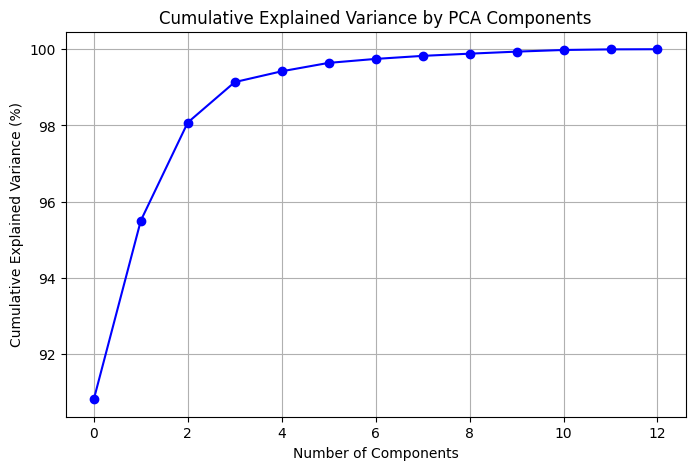

In [39]:
# TODO: Mean-center the data, apply PCA, and extract the principal components.
mean = np.mean(X, axis=0)
X_centered = X - mean
pca = PCA()
x_pca = pca.fit_transform(X_centered)


# TODO: Calculate the percentage of variance explained by the first three components.
# Store these percentages in 'var_pc1', 'var_pc2', and 'var_pc3' (e.g., 90.5 for 90.5%).
variance_ratios = pca.explained_variance_ratio_
var_pc1 = variance_ratios[0] * 100
var_pc2 = variance_ratios[1] * 100
var_pc3 = variance_ratios[2] * 100

print(f"Variance Explained by PC1: {var_pc1:.2f}%")
print(f"Variance Explained by PC2: {var_pc2:.2f}%")
print(f"Variance Explained by PC3: {var_pc3:.2f}%")


# TODO: Plot the Cumulative Explained Variance.
cumulative_variance = np.cumsum(variance_ratios) * 100
plt.figure(figsize=(8, 5))
plt.plot(
    cumulative_variance,
    marker="o",
    linestyle="-",
    color="b",
    label="Cumulative Explained Variance",
)
plt.title("Cumulative Explained Variance by PCA Components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.grid()
plt.show()

### 4. Physical Interpretability
Let's calculate three physical metrics from our flattened original data `X`:
* `Brightness` = Mean of Visible + NIR bands (B2, B3, B4, B8)
* `NDVI` = (B8 - B4) / (B8 + B4)
* `NDWI` = (B3 - B8) / (B3 + B8)

*(Note: Sentinel-2 array indices: B2=1, B3=2, B4=3, B8=7)*


In [40]:
# TODO: Calculate Brightness, NDVI, and NDWI using the specified bands.
# TODO: Implement Min-Max scaling to normalize your 3 handcrafted indices AND the first 3 Principal Components to a [0, 1] range.


def handle_flipping(real_val, pca_value):
    if (
        np.corrcoef(real_val, pca_value)[0, 1] < 0
    ):  # If negatively correlated, flip the sign of the PCA component
        return -1 * pca_value
    return pca_value


# Sentinel-2 Bands: B2 (Blue), B3 (Green), B4 (Red), B8 (NIR)
B2 = X[:, 1]
B3 = X[:, 2]
B4 = X[:, 3]
B8 = X[:, 7]

# Adding a small constant to avoid division by zero
NDVI = (B8 - B4) / (B8 + B4 + 1e-6)  # Detect vegetation greenness and health
NDWI = (B3 - B8) / (B3 + B8 + 1e-6)  # Detect water bodies and moisture in vegetation

Brightness = (B2 + B3 + B4 + B8) / 4

pc_1 = handle_flipping(Brightness, x_pca[:, 0])
pc_2 = handle_flipping(NDVI, x_pca[:, 1])
pc_3 = handle_flipping(NDWI, x_pca[:, 2])

total_features = np.column_stack((Brightness, NDVI, NDWI, pc_1, pc_2, pc_3))

minmaxscaler = MinMaxScaler()
scaled_features = minmaxscaler.fit_transform(total_features)
scaled_brightness, scaled_ndvi, scaled_ndwi, scaled_pc1, scaled_pc2, scaled_pc3 = (
    scaled_features[:, 0],
    scaled_features[:, 1],
    scaled_features[:, 2],
    scaled_features[:, 3],
    scaled_features[:, 4],
    scaled_features[:, 5],
)

### 5. Evaluating the Math (L1 Loss)
Calculate the Mean Absolute Error (L1 Loss) to see how closely the abstract Principal Components match the physical equations.
* Compare PC1 vs Brightness
* Compare PC2 vs NDVI
* Compare PC3 vs NDWI

**Advisory:** The mathematical direction (sign) of a Principal Component eigenvector is arbitrary. Be mindful of inversely related data before calculating your error.


In [41]:
def calc_l1_loss(true_arr, pred_arr):
    return np.mean(np.abs(true_arr - pred_arr))


# TODO: Calculate the L1 loss between the physical indices and their corresponding PCs.
# Store the results in 'loss_pc1_bright', 'loss_pc2_ndvi', and 'loss_pc3_ndwi'.

loss_pc1_bright = calc_l1_loss(scaled_brightness, scaled_pc1)
loss_pc2_ndvi = calc_l1_loss(scaled_ndvi, scaled_pc2)
loss_pc3_ndwi = calc_l1_loss(scaled_ndwi, scaled_pc3)

print(f"L1 Loss (PC1 vs Brightness): {loss_pc1_bright:.2f}")
print(f"L1 Loss (PC2 vs NDVI): {loss_pc2_ndvi:.2f}")
print(f"L1 Loss (PC3 vs NDWI): {loss_pc3_ndwi:.2f}")

L1 Loss (PC1 vs Brightness): 0.02
L1 Loss (PC2 vs NDVI): 0.14
L1 Loss (PC3 vs NDWI): 0.11


### 6. Analysis Questions

**Question 1:** Based on your Cumulative Variance calculations, what is the minimum number of Principal Components required to retain $\ge 95\%$ of the total variance in this dataset? 
*(You will add your integer answer to the final submission dictionary under the key `ans1`)*

**Question 2:** Analyze your L1 Loss results. Which PCs aligned well with known physical features, and which did not? Based on the properties of this dataset (a Level-1C image over an urban area), formulate a hypothesis explaining the physical meaning of the third principal component (PC3) and what PCA is isolating in this lower-variance component.
*(You will add your written analysis to the final submission dictionary under the key `ans2`)*


### 7. Submission Cell
Run this cell to generate your final submission payload.


In [42]:
import json

submission_data = {
    "ids": [9220475, 9220681],  # "your_student_id_here",
    "max_corr": round(float(max_corr), 2),
    "min_corr": round(float(min_corr), 2),
    "var_pc1": round(float(var_pc1), 2),
    "var_pc2": round(float(var_pc2), 2),
    "var_pc3": round(float(var_pc3), 2),
    "loss_pc1_bright": round(float(loss_pc1_bright), 2),
    "loss_pc2_ndvi": round(float(loss_pc2_ndvi), 2),
    "loss_pc3_ndwi": round(float(loss_pc3_ndwi), 2),
    "ans1": 2,
    "ans2": """
First: PC1 was well aligned with Brightness, showing a strong correlation and low L1 loss, indicating that the first principal component captures overall brightness variations in the image, while
PC2 and PC3 had higher L1 losses with NDVI and NDWI, suggesting they capture more complex spectral information that doesn't directly correspond to these indices because the image
itself was captured in an urban area so, NDWI and NDVI contribute less to the overall variance.

Second: PC3 represents a low-variance component that captures subtle variations in the data which maybe a noise or minor features that don't dominate the variance, so PCA isolates
those features into later components.
""",
    "notes": [
        """The array indices are the same as the band which was removed was the 9th column which comes later in the sequence, so no changes occurred""",
        """Since, the Level-1C image contained haze, it added an extra variance which PC3 accidentially aligned with NDWI resulting in a smaller L1 loss, but for the Level-2A
image hadn't any haze, so the urban areas are more clear, for that the NDWI variations are tiny, causing more L1 loss
""",
    ],  # For any additional comments or observations you have about the results can go here
    "msgs": [],  # For any messages you want to convey to the TAs
}

print("AUTOGRADER_OUTPUT_START")
print(json.dumps(submission_data, indent=4))
print("AUTOGRADER_OUTPUT_END")

AUTOGRADER_OUTPUT_START
{
    "ids": [
        9220475,
        9220681
    ],
    "max_corr": 0.99,
    "min_corr": 0.55,
    "var_pc1": 90.81,
    "var_pc2": 4.69,
    "var_pc3": 2.58,
    "loss_pc1_bright": 0.02,
    "loss_pc2_ndvi": 0.14,
    "loss_pc3_ndwi": 0.11,
    "ans1": 2,
    "ans2": "\nFirst: PC1 was well aligned with Brightness, showing a strong correlation and low L1 loss, indicating that the first principal component captures overall brightness variations in the image, while\nPC2 and PC3 had higher L1 losses with NDVI and NDWI, suggesting they capture more complex spectral information that doesn't directly correspond to these indices because the image\nitself was captured in an urban area so, NDWI and NDVI contribute less to the overall variance.\n\nSecond: PC3 represents a low-variance component that captures subtle variations in the data which maybe a noise or minor features that don't dominate the variance, so PCA isolates\nthose features into later components.\n",
 

### 8. Bonus Challenge: Ground Truth Comparison (Level-2A)
You have just analyzed `hazy_cufe.tiff`, which is a Level-1C (Top of Atmosphere) image containing 13 bands, including the B10 Cirrus band which is highly sensitive to atmospheric noise and haze.

Provided in your data folder is another image: `gt_cufe.tiff`. This is a Level-2A (Surface Reflectance) "Ground Truth" image that has been atmospherically corrected. 
* **Note:** The Level-2A image only has **12 bands** because the B10 Cirrus band is removed after atmospheric correction.

**The Challenge:**
1. Change the `image_path` in Cell 3 to `"gt_cufe.tiff"` and rerun the entire notebook. 
2. *Advisory:* Double-check your array indices for calculating Brightness, NDVI, and NDWI. Since the Level-2A image dropped a band, did the column indices for B2, B3, B4, and B8 shift, or did the dropped band come later in the sequence?
3. **Analyze the differences:** How does the removal of atmospheric haze and the B10 band affect the Variance Explained by the Principal Components? Specifically, look at PC3. What does PC3 represent now that the atmospheric noise is gone? Does its L1 loss against physical indices improve?

*If you complete this challenge, add your comparative analysis as a string inside the `"notes"` list in your final submission dictionary!*
